# Neural Estate's Woningprijs Voorspeller

## 0 Teaminformatie

- **Team naam**: Groep 5
- **Namen**: Imran Funna, Rinesh Nanda
- **Kaggle Imran**: imranfunna
- **Kaggle Rinesh**: 

In [3]:
# Alle imports
from pathlib import Path
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

import tensorflow as tf
from tensorflow.keras import callbacks, layers, models
from tensorflow.keras.utils import plot_model

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1 Inleiding


**Neural Estate** is een vastgoedtechnologiebedrijf wat slimme tools ontwikkelt voor makelaars, investeerders en huizenkopers waardoor zij een schatting kunnen krijgen op basis van visuele en numerieke data. Hun doel is dan ook om de woningmarkt te revolutioneren met AI.

Het belangrijkste product van Neural Estate is een AI powered ratingsystem dat de verkoopprijzen van huizen kan voorspellen. Om dit systeem te kunnen verbeteren heeft Neural Estate een grote woningsdataset verzameld uit 2016. De prijzen zijn niet meer actueel maar vormen nog steeds een realistische benchmark voor het bouwen van ml-modellen. 

Aan ons, een team juniore data scientists, wordt gevraagd om te helpen door een **neuraal netwerkmodel** te ontwerpen en te trainen dat de **verkoopprijs** zo nauwkeurig mogelijk voorspelt.

## 2 Dataset

Voor het bouwen van het neurale netwerkmodel hebben we data gekregen. Dat zijn twee soorten data:

1. Image Data
    - Slaapkamer
    - Badkamer
    - Keuken
    - Vooraanzicht

Deze vier afbeeldingen zijn samengevoegd tot één enkele afbeelding per huis. Wij zullen dit gebruiken als input voor een computer vision model.

2. Tabulair Data:
    - Oppervlakte
    - Aantal kamers
    - Lat- en Longitude
    - Prijs

## 3 EDA


In [4]:
df = pd.read_csv('train.csv')
display(df.head())

,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.0,4053,33.6968,-111.8892,869500
1,2,4,3.0,3343,34.8280,-119.0349,865200
2,3,3,4.0,3923,33.7669,-111.9182,889000
3,4,5,5.0,4022,33.7752,-111.7791,910000
4,5,3,4.0,4116,33.7669,-111.9182,971226


### 3.1 Afbeeldingen inlezen en voorbeelden tonen

We laden de trainingsmetadata en tonen enkele voorbeeldafbeeldingen uit de map `Train`.

Aantal rijen in metadata: 500
Aantal kolommen: 7


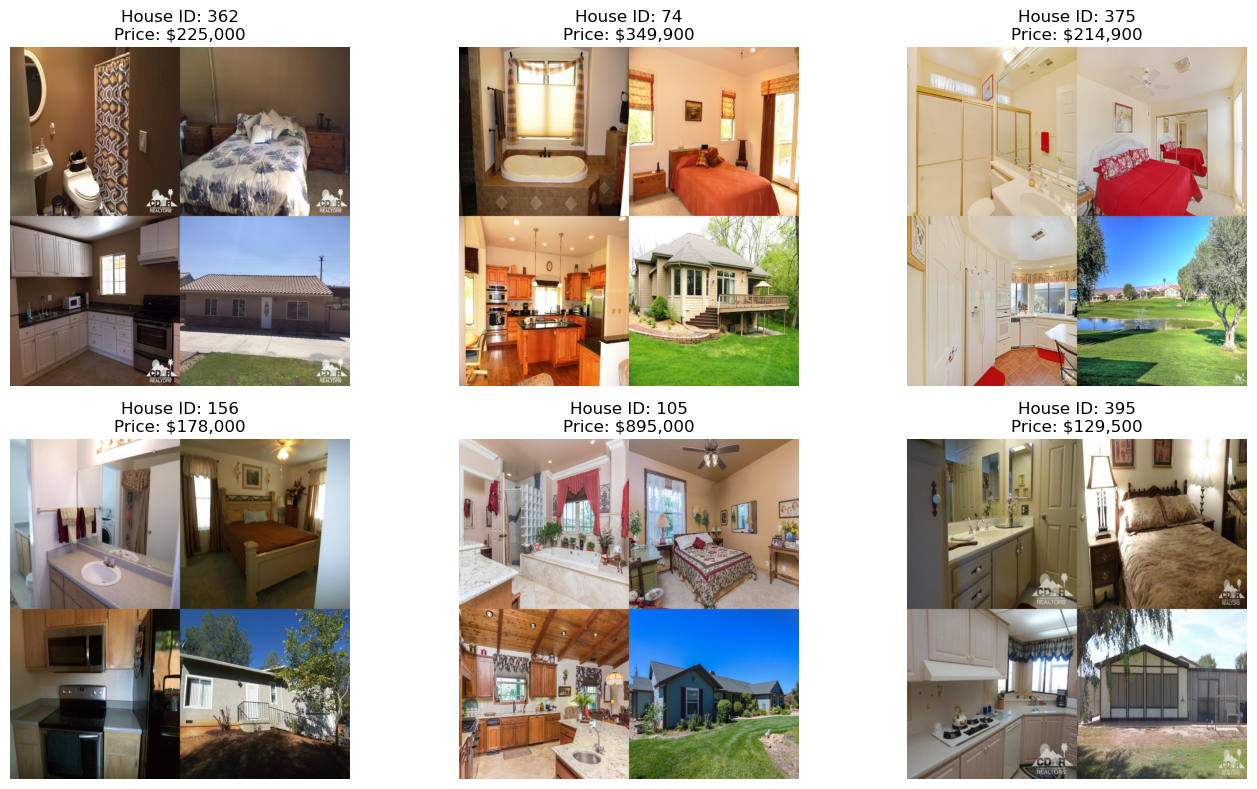

In [5]:
# Folder naam definieren
images_dir = Path('Train')

# Size en shape
print(f'Aantal rijen in metadata: {len(df)}')
print(f'Aantal kolommen: {df.shape[1]}')

# Enkele afbeeldingen dus we nemen 6 met fixed random state
sample_df = df.sample(6, random_state=42)

# Subplots maken
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# ID en prijs geven voor elke subplot
for ax, (_, row) in zip(axes, sample_df.iterrows()):

    # ID naar int en dan zoeken naar ID foto in Train folder
    house_id = int(row['House ID'])
    image_path = images_dir / f'{house_id}.jpg'

    # Foto inladen en laten zien met relevante info
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_title(f"House ID: {house_id}\nPrice: ${row['Price']:,.0f}")

    ax.axis('off')

for ax in axes[len(sample_df):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Hier staan een voorbeeld van enkele huizen zoals ze voorkomen in de dataset. ID en prijs is erbij gezet per huis.

### 3.2 Metadata analyseren en relaties met targetvariabele onderzoeken

We onderzoeken de relatie tussen `Price` (target) en de andere variabelen via samenvattingen en visualisaties.


Ontbrekende waarden per kolom:


,missing_values
House ID,0
Bedrooms,0
Bathrooms,0
Area,0
Latitude,0
Longitude,0
Price,0



Beschrijvende statistiek:


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,250.500000,3.350000,2.669500,2369.64600,35.128844,-116.469049,5.980218e+05
std,144.481833,1.172283,1.017578,1208.18261,2.386173,6.554434,5.240649e+05
min,1.000000,1.000000,1.000000,701.00000,32.631500,-122.368300,2.200000e+04
25%,125.750000,2.000000,2.000000,1440.00000,33.808200,-119.802500,2.350000e+05
50%,250.500000,3.000000,2.500000,2097.50000,33.920800,-117.609600,5.300000e+05
75%,375.250000,4.000000,3.000000,3104.50000,35.640600,-116.371300,7.490000e+05
max,500.000000,10.000000,7.000000,9583.00000,47.791800,-87.885900,5.858000e+06


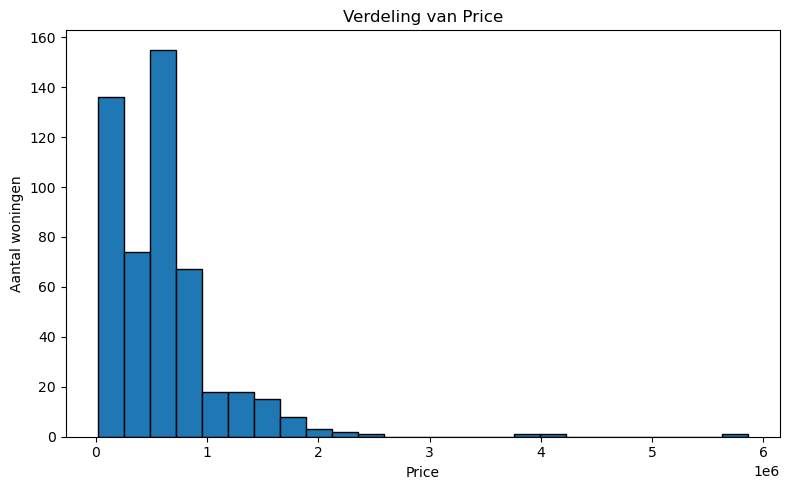

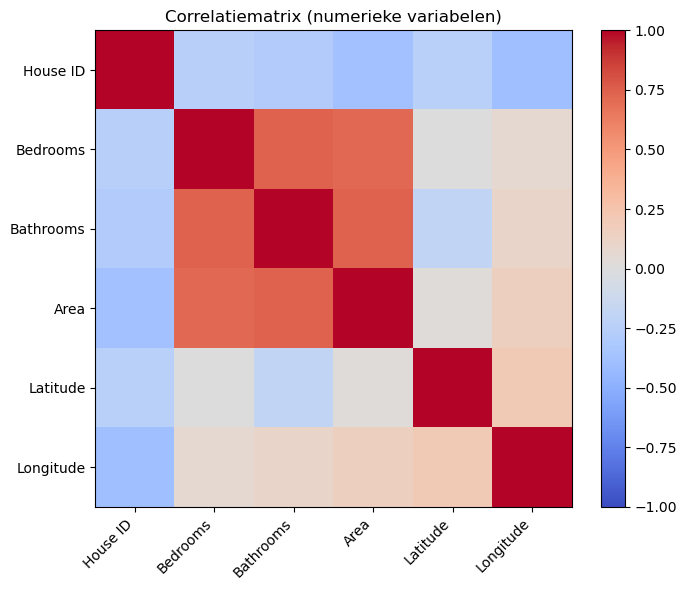

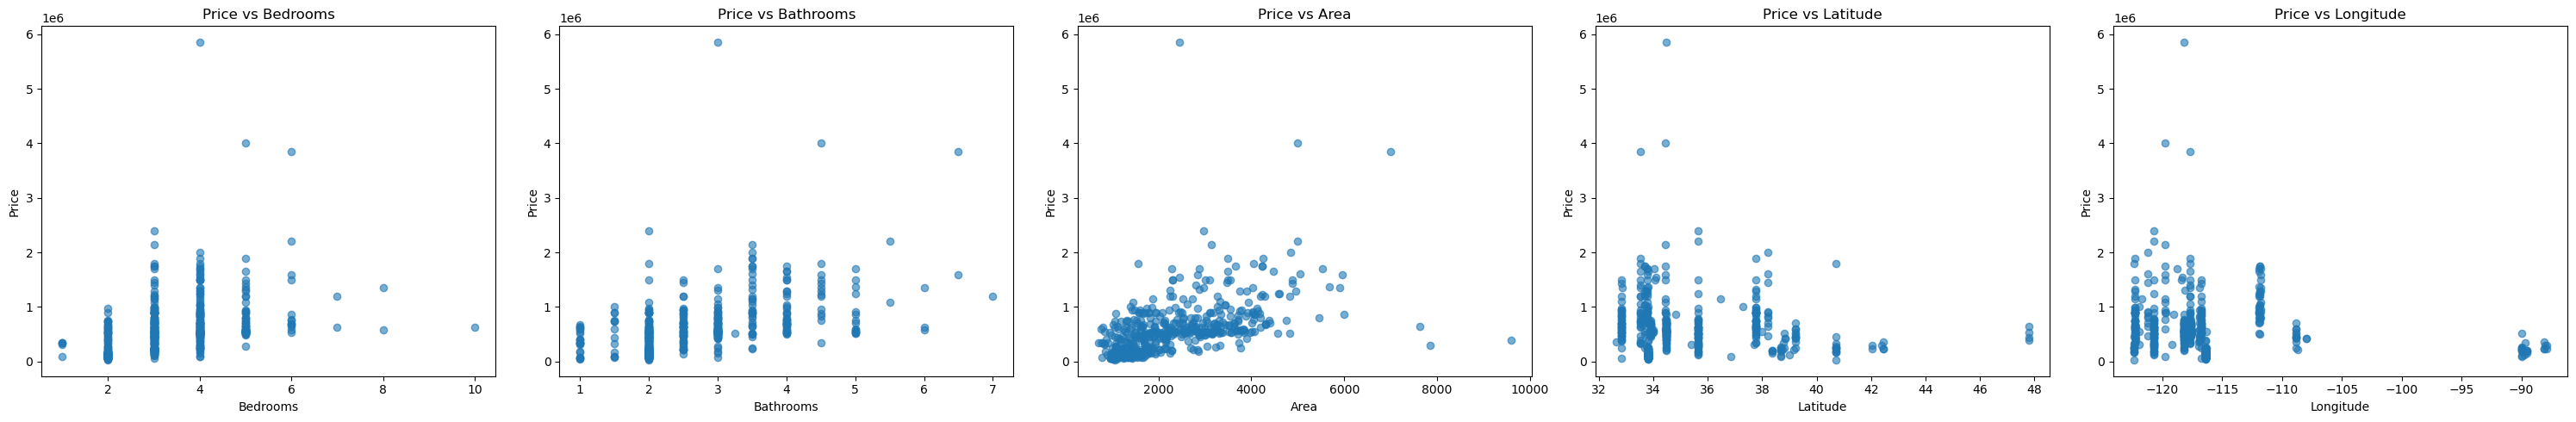

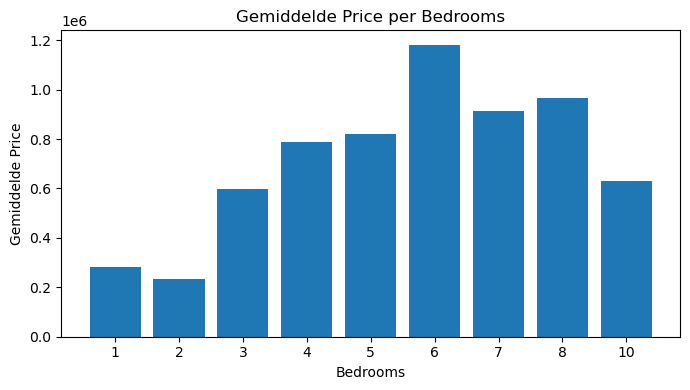

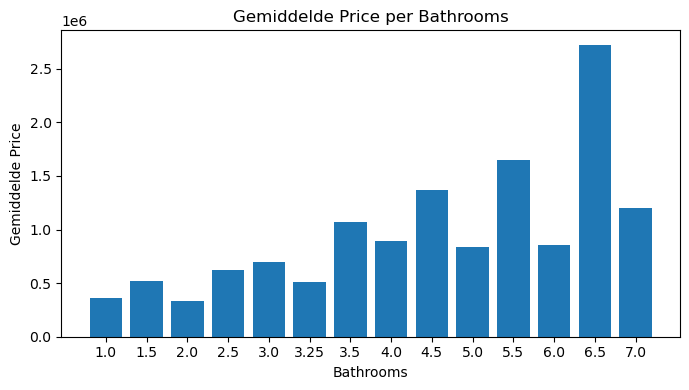

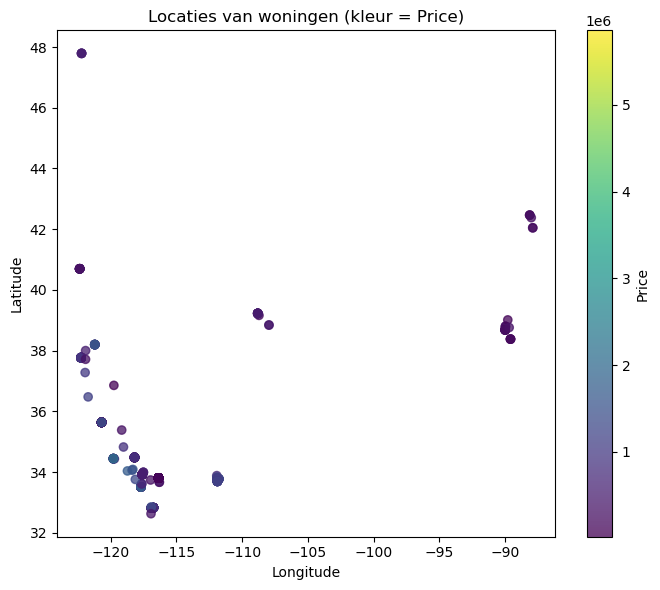

In [6]:
# We maken een lijst van de features (dus geen Price)
feature_cols = [col for col in df.columns if col != 'Price']

# We kijken of er ontbrekende waardes zijn en hoeveel
print('\nOntbrekende waarden per kolom:')
display(df.isna().sum().to_frame('missing_values'))

# Beschrijvende statistieken
print('\nBeschrijvende statistiek:')
display(df.describe(include='all'))

# We kijken naar de verdeling van de prijs
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Price'], bins=25, edgecolor='black')
ax.set_title('Verdeling van Price')
ax.set_xlabel('Price')
ax.set_ylabel('Aantal woningen')
plt.tight_layout()
plt.show()

# We kijken naar correlaties tussen de features
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlatiematrix (numerieke variabelen)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#Relatie Price vs elke feature (excl. House ID)
plot_features = [c for c in feature_cols if c not in ['Price', 'House ID']]

n = len(plot_features)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, plot_features):
    ax.scatter(df[col], df['Price'], alpha=0.6)
    ax.set_title(f'Price vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

#Gemiddelde prijs per aantal slaapkamers/badkamers
for group_col in ['Bedrooms', 'Bathrooms']:
    if group_col in df.columns:
        grouped = df.groupby(group_col)['Price'].mean().sort_index()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(grouped.index.astype(str), grouped.values)
        ax.set_title(f'Gemiddelde Price per {group_col}')
        ax.set_xlabel(group_col)
        ax.set_ylabel('Gemiddelde Price')
        plt.tight_layout()
        plt.show()

# Locatieplot (Latitude/Longitude) gekleurd op Price
if {'Latitude', 'Longitude', 'Price'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(df['Longitude'], df['Latitude'], c=df['Price'], cmap='viridis', alpha=0.75)
    ax.set_title('Locaties van woningen (kleur = Price)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Price')
    plt.tight_layout()
    plt.show()

### 3.3 Bevindingen

Na het uitvoeren van de EDA zijn we tot bepaalde conclusies gekomen.

1. Huizen kunnen zo goedkoop zijn als `$22.000` en oplopen tot `$5.858.000` zoals we hebben gezien in de beschrijvende statistieken.
2. Over het algemeen zijn de prijzen van de huizen aan de lagere kant van het spectrum, zoals we hebben gezien in de rechtsscheve verdelingen van de prijzen. Dit betekent dat de echt dure huizen (Bijvoorbeeld die van $5.858.000) duidelijk outliers zijn en de prijzen over het algemeen dichter op elkaar zitten en steeds minder voorkomt hoe hoger de prijs stijgt.
3. Zoals te zien in de correlatiematrix zien we dat `Area`, `Bedrooms` en `Bathrooms` een sterke **positieve** correlatie hebben met elkaar.
4. Als we kijken naar de kleinere subplots en dan inzoomen op `Area vs. Price` zien we dat over het algemeen hoe lager de area is, hoe lager de prijs is, met enkele uitschieters.
5. Als laatst zien we in de location plot dat huizen met een lagere lat- en longitude een wat hogere prijs hebben dan de locaties die een hogere lat- of longitude hebben.

## 4 Fully connected neuraal netwerk

### 4.1 Keuzes en motivatie

Voor deze deelopdracht gebruiken we alleen de **tabulaire variabelen** (`Area`, `Bedrooms`, `Bathrooms`, `Latitude`, `Longitude`) en voorspellen we `Price` met een dense neuraal netwerk.

- **Aantal lagen / neuronen**: we kiezen een compact MLP met 3 hidden layers (`128 -> 64 -> 32`). Dit geeft genoeg capaciteit voor niet-lineaire relaties zonder het model onnodig groot te maken.
- **Activeringsfunctie**: `ReLU` in hidden layers, omdat deze stabiel traint en effectief is voor regressieproblemen met geschaalde features.
- **Outputlaag**: 1 neuron met lineaire activatie, omdat we een continue waarde (prijs) voorspellen.
- **Lossfunctie**: we kiezen **MSE** (`mean_squared_error`) als primaire loss, omdat grote fouten bij prijsvoorspelling extra moeten doorwegen. Daarnaast rapporteren we `MAE` en `RMSE` als interpreteerbare metrics.
- **Optimizer**: **Adam** (`learning_rate=1e-3`), een optimizer die per parameter een adaptieve learning rate gebruikt via exponentieel voortschrijdende gemiddelden van gradiënten (eerste en tweede moment), wat vaak snelle en stabiele convergentie geeft.
- **Epochs**: maximaal 150 epochs met `EarlyStopping`; zo krijgt het model voldoende leertijd, maar stopt het automatisch zodra de validatiefout niet meer verbetert.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model

# Reproduceerbaarheid
tf.random.set_seed(42)
np.random.seed(42)

# Zorg dat df beschikbaar is
if 'df' not in globals():
    import pandas as pd
    df = pd.read_csv('train.csv')

# Alleen tabulaire features gebruiken
X = df.drop(columns=['Price', 'House ID'], errors='ignore').copy()
y = df['Price'].astype('float32').copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling voor stabielere NN training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Door scheve prijsverdeling trainen we op log-prijs
y_train_log = np.log1p(y_train.values)
y_val_log = np.log1p(y_val.values)

print(f'Train shape: {X_train_scaled.shape}, Validatie shape: {X_val_scaled.shape}')
print('Features gebruikt:', list(X.columns))

Train shape: (400, 5), Validatie shape: (100, 5)
Features gebruikt: ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.


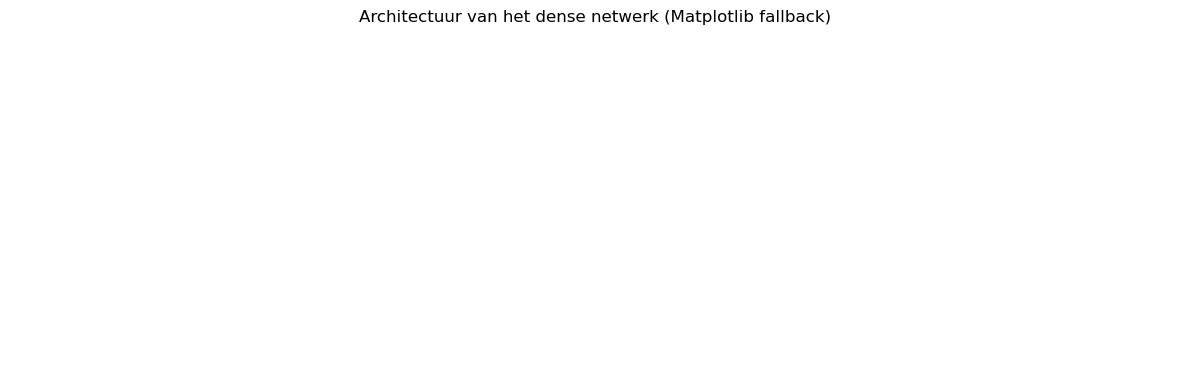

In [8]:
# Dense (fully-connected) regressiemodel
model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name='input_tabular'),
    layers.Dense(128, activation='relu', name='dense_128'),
    layers.Dense(64, activation='relu', name='dense_64'),
    layers.Dense(32, activation='relu', name='dense_32'),
    layers.Dense(1, activation='linear', name='price_output')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

model.summary()

# Architectuurplot opslaan en tonen
plot_path = Path('dense_model_architecture.png')

try:
    plot_model(
        model,
        to_file=str(plot_path),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(mpimg.imread(plot_path))
    ax.axis('off')
    ax.set_title('Architectuur van het dense netwerk (Keras plot_model)')
    plt.tight_layout()
    plt.show()
except Exception:
    print('visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Architectuur van het dense netwerk (Matplotlib fallback)')
    plt.tight_layout()
    plt.show()

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 155.1787 - mae: 12.4229 - rmse: 12.4571 - val_loss: 133.1383 - val_mae: 11.4875 - val_rmse: 11.5386
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 119.8514 - mae: 10.8495 - rmse: 10.9477 - val_loss: 85.0489 - val_mae: 8.9295 - val_rmse: 9.2222
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 68.6262 - mae: 7.9347 - rmse: 8.2841 - val_loss: 36.8382 - val_mae: 5.6679 - val_rmse: 6.0695
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28.5769 - mae: 4.4403 - rmse: 5.3457 - val_loss: 28.4013 - val_mae: 3.8117 - val_rmse: 5.3293
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.0899 - mae: 3.4410 - rmse: 4.3692 - val_loss: 16.1146 - val_mae: 3.1069 - val_rmse: 4.0143
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.5879 - mae: 2.9910 - rmse: 3.6862 - val_loss: 11.3243 - val_mae: 2.4468 - val_rmse: 3.3652
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.8394 - mae

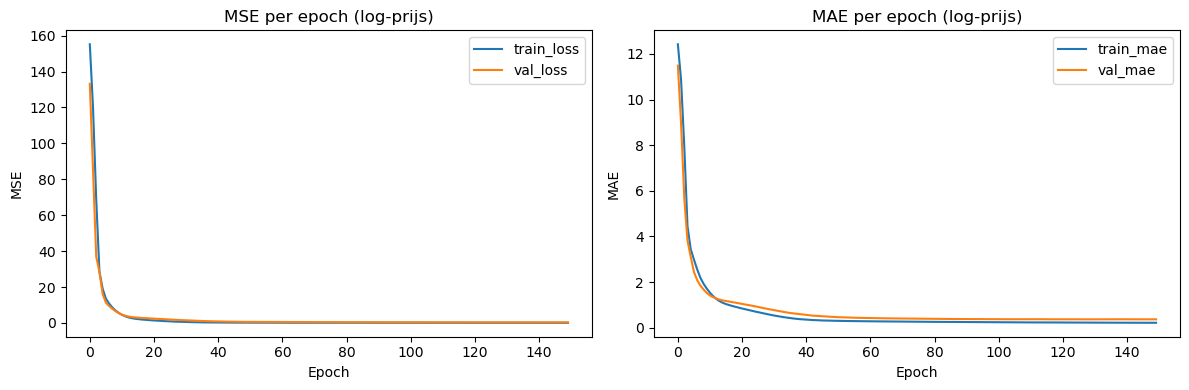

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Validatie MAE (prijs-schaal): $357,576.12
Validatie RMSE (prijs-schaal): $1,434,049.25
Totaal getrainde epochs: 150


In [9]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Leerproces visualiseren
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'], label='train_mae')
axes[1].plot(history.history['val_mae'], label='val_mae')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluatie op originele prijsschaal
val_pred_log = model.predict(X_val_scaled).reshape(-1)
val_pred_price = np.expm1(val_pred_log)
val_true_price = np.expm1(y_val_log)

val_mae_price = mean_absolute_error(val_true_price, val_pred_price)
val_rmse_price = np.sqrt(mean_squared_error(val_true_price, val_pred_price))

print(f'Validatie MAE (prijs-schaal): ${val_mae_price:,.2f}')
print(f'Validatie RMSE (prijs-schaal): ${val_rmse_price:,.2f}')
print(f'Totaal getrainde epochs: {len(history.history["loss"])}')

bron: https://campus.datacamp.com/courses/introduction-to-deep-learning-in-python/fine-tuning-keras-models?ex=6

## Convolutioneel neuraal netwerk from scratch 

In [69]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


In [70]:
df = pd.read_csv("train.csv")

df["image_path"] = df["House ID"].apply(lambda x: os.path.join("Train", f"{x}.jpg"))

nolabel = df[["image_path", "Price"]].copy()
nolabel = nolabel.rename(columns={"Price": "price"})

# eerst log-transform
nolabel["price"] = np.log1p(nolabel["price"])

print(nolabel.head())
print("Log-prijs min:", nolabel["price"].min())
print("Log-prijs max:", nolabel["price"].max())

    image_path      price
0  Train\1.jpg  13.675675
1  Train\2.jpg  13.670717
2  Train\3.jpg  13.697854
3  Train\4.jpg  13.721201
4  Train\5.jpg  13.786315
Log-prijs min: 9.99884318585288
Log-prijs max: 15.583318977076527


In [71]:
nolabel["exists"] = nolabel["image_path"].apply(os.path.exists)
print(nolabel["exists"].value_counts())

nolabel = nolabel[nolabel["exists"] == True].copy()
nolabel = nolabel[["image_path", "price"]]

exists
True    500
Name: count, dtype: int64


In [72]:
train_df, val_df = train_test_split(nolabel, test_size=0.2, random_state=42)

print("Aantal train:", len(train_df))
print("Aantal validatie:", len(val_df))

Aantal train: 400
Aantal validatie: 100


In [73]:
price_mean = train_df["price"].mean()
price_std = train_df["price"].std()

train_df = train_df.copy()
val_df = val_df.copy()

train_df["price_scaled"] = (train_df["price"] - price_mean) / price_std
val_df["price_scaled"] = (val_df["price"] - price_mean) / price_std

print("price_mean:", price_mean)
print("price_std:", price_std)

print("Train scaled min:", train_df["price_scaled"].min())
print("Train scaled max:", train_df["price_scaled"].max())
print("Val scaled min:", val_df["price_scaled"].min())
print("Val scaled max:", val_df["price_scaled"].max())

price_mean: 12.987615284158224
price_std: 0.8958068597148604
Train scaled min: -3.336402334825482
Train scaled max: 2.8976153338952186
Val scaled min: -2.590921072237886
Val scaled max: 1.8043544444727342


In [74]:
IMG_HEIGHT = 160
IMG_WIDTH = 160
BATCH_SIZE = 8

In [75]:
train_paths = train_df["image_path"].values
train_labels = train_df["price_scaled"].values.astype("float32")

val_paths = val_df["image_path"].values
val_labels = val_df["price_scaled"].values.astype("float32")

print("train_labels min:", train_labels.min())
print("train_labels max:", train_labels.max())
print("val_labels min:", val_labels.min())
print("val_labels max:", val_labels.max())

train_labels min: -3.3364024
train_labels max: 2.8976154
val_labels min: -2.5909212
val_labels max: 1.8043544


In [76]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    return image, label

In [77]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = train_ds.map(load_image, num_parallel_calls=1)
val_ds = val_ds.map(load_image, num_parallel_calls=1)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(1)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(1)

In [78]:
for images, labels in val_ds.take(1):
    print("labels min in val_ds batch:", tf.reduce_min(labels).numpy())
    print("labels max in val_ds batch:", tf.reduce_max(labels).numpy())

labels min in val_ds batch: -1.3980007
labels max in val_ds batch: 0.8003565


In [79]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.03),
])

In [80]:
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="linear")
])

In [90]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.LogCosh(),
    metrics=["mae"]
)

In [91]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 353ms/step - loss: 0.2806 - mae: 0.6414 - val_loss: 0.4015 - val_mae: 0.8136 - learning_rate: 1.0000e-04
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - loss: 0.2821 - mae: 0.6607 - val_loss: 0.4236 - val_mae: 0.8386 - learning_rate: 1.0000e-04
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 0.2781 - mae: 0.6509 - val_loss: 0.4001 - val_mae: 0.8015 - learning_rate: 1.0000e-04
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - loss: 0.2525 - mae: 0.6165 - val_loss: 0.3283 - val_mae: 0.7032 - learning_rate: 1.0000e-04
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - loss: 0.2611 - mae: 0.6220 - val_loss: 0.3287 - val_mae: 0.7080 - learning_rate: 1.0000e-04
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - loss: 0.2469 - mae: 0.6028 - val_loss: 0.4100 - val_mae: 0.8185 - learning_rate: 1.0000e-04
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - loss: 0.2383 - mae: 0.5917 - val_loss: 0.3257 - val_mae: 0.70

In [92]:
predictions_scaled = model.predict(val_ds, verbose=0).flatten()
true_prices_scaled = np.concatenate([y.numpy() for x, y in val_ds], axis=0).flatten()

print("predictions_scaled min:", np.min(predictions_scaled))
print("predictions_scaled max:", np.max(predictions_scaled))
print("true_prices_scaled min:", np.min(true_prices_scaled))
print("true_prices_scaled max:", np.max(true_prices_scaled))

predictions_scaled min: -1.7358265
predictions_scaled max: 0.8792983
true_prices_scaled min: -2.5909212
true_prices_scaled max: 1.8043544


In [93]:
predictions_log = (predictions_scaled * price_std) + price_mean
true_prices_log = (true_prices_scaled * price_std) + price_mean

print("predictions_log min:", np.min(predictions_log))
print("predictions_log max:", np.max(predictions_log))
print("true_prices_log min:", np.min(true_prices_log))
print("true_prices_log max:", np.max(true_prices_log))

predictions_euro = np.expm1(predictions_log)
true_prices_euro = np.expm1(true_prices_log)

mae_euro = mean_absolute_error(true_prices_euro, predictions_euro)
print(f"\nMAE in euro: €{mae_euro:,.0f}")

for i in range(min(10, len(predictions_euro))):
    print(f"Voorspeld: €{predictions_euro[i]:,.0f} | Echt: €{true_prices_euro[i]:,.0f}")

predictions_log min: 11.432651
predictions_log max: 13.775297
true_prices_log min: 10.666651
true_prices_log max: 14.603969

MAE in euro: €253,148
Voorspeld: €249,700 | Echt: €225,000
Voorspeld: €779,260 | Echt: €349,900
Voorspeld: €518,516 | Echt: €214,900
Voorspeld: €227,574 | Echt: €178,000
Voorspeld: €770,136 | Echt: €895,000
Voorspeld: €331,315 | Echt: €129,500
Voorspeld: €126,228 | Echt: €124,900
Voorspeld: €823,270 | Echt: €825,500
Voorspeld: €204,222 | Echt: €94,500
Voorspeld: €738,837 | Echt: €599,999


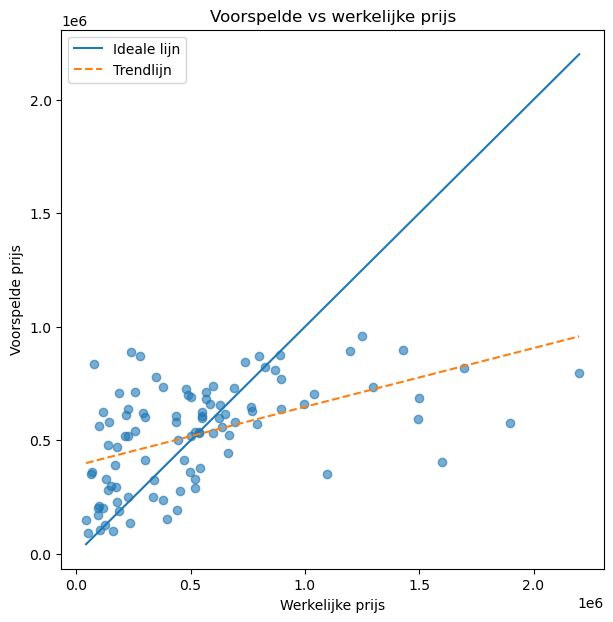

In [94]:
plt.figure(figsize=(7, 7))
plt.scatter(true_prices_euro, predictions_euro, alpha=0.6)

min_val = min(true_prices_euro.min(), predictions_euro.min())
max_val = max(true_prices_euro.max(), predictions_euro.max())

plt.plot([min_val, max_val], [min_val, max_val], label="Ideale lijn")

z = np.polyfit(true_prices_euro, predictions_euro, 1)
p = np.poly1d(z)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, p(x_line), linestyle="--", label="Trendlijn")

plt.xlabel("Werkelijke prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Voorspelde vs werkelijke prijs")
plt.legend()
plt.show()

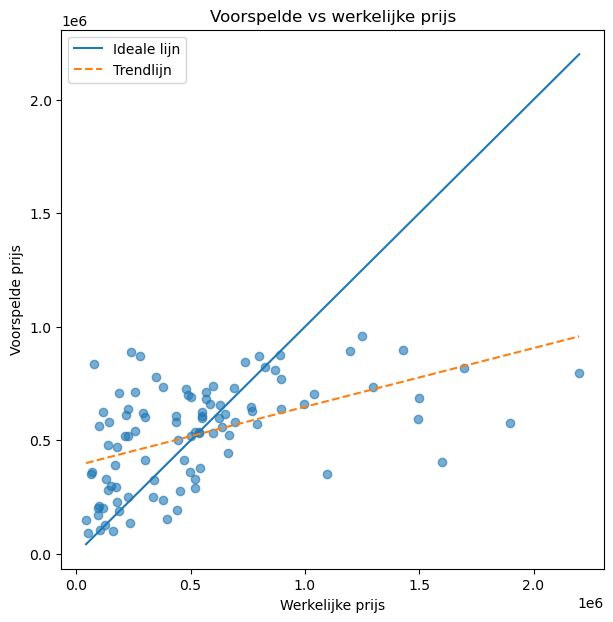

In [95]:
plt.figure(figsize=(7, 7))
plt.scatter(true_prices_euro, predictions_euro, alpha=0.6)

min_val = min(true_prices_euro.min(), predictions_euro.min())
max_val = max(true_prices_euro.max(), predictions_euro.max())

plt.plot([min_val, max_val], [min_val, max_val], label="Ideale lijn")

z = np.polyfit(true_prices_euro, predictions_euro, 1)
p = np.poly1d(z)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, p(x_line), linestyle="--", label="Trendlijn")

plt.xlabel("Werkelijke prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Voorspelde vs werkelijke prijs")
plt.legend()
plt.show()

In [96]:
import pandas as pd
import os
import numpy as np
import tensorflow as tf

# Testbestand inladen
test_df = pd.read_csv("test.csv")

# Pad naar testafbeeldingen maken
test_folder = "Test"
test_df["image_path"] = test_df["House ID"].apply(lambda x: os.path.join(test_folder, f"{x}.jpg"))

print(test_df.head())
print(test_df.shape)

   House ID  Bedrooms  Bathrooms  Area  Latitude  Longitude    image_path
0       501         3        2.0  2330   35.6406  -120.7003  Test\501.jpg
1       502         3        2.5  1339   35.6406  -120.7003  Test\502.jpg
2       503         3        2.0  1472   35.6406  -120.7003  Test\503.jpg
3       504         4        4.0  2681   35.6406  -120.7003  Test\504.jpg
4       505         3        2.5  1935   33.8085  -117.9228  Test\505.jpg
(35, 7)


In [97]:
# Alleen paden ophalen
test_paths = test_df["image_path"].values

def load_test_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    return image

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(load_test_image, num_parallel_calls=1)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(1)

In [98]:
# Voorspellingen op testset
test_predictions_scaled = model.predict(test_ds, verbose=0).flatten()

# Terug van scaled -> log
test_predictions_log = (test_predictions_scaled * price_std) + price_mean

# Terug van log -> euro
test_predictions_euro = np.expm1(test_predictions_log)

print(test_predictions_euro[:10])

[666191.   708596.94 747733.44 673626.2  375887.75 653469.56 256421.12
 496150.88 878499.9  642262.  ]


In [100]:
submission = pd.DataFrame({
    "House ID": test_df["House ID"],
    "Price": test_predictions_euro
})

print(submission.head())

   House ID        Price
0       501  666191.0000
1       502  708596.9375
2       503  747733.4375
3       504  673626.1875
4       505  375887.7500


In [101]:
submission.to_csv("submission.csv", index=False)
print("submission.csv is opgeslagen")

submission.csv is opgeslagen


# Onderbouwing modelkeuzes CNN

## Modelarchitectuur

Voor het convolutionele neurale netwerk is gekozen voor vier convolutionele lagen, waarbij het aantal filters per laag oploopt van 32 naar 64, 128 en 256. Het idee hierachter is dat het model eerst simpele dingen leert, zoals randen en vormen, en daarna steeds complexere kenmerken, zoals hoe een huis eruitziet (bijvoorbeeld ramen, dakvorm of de stijl van de woning). Door in de diepere lagen meer filters te gebruiken, kan het model meer verschillende patronen herkennen.

Na elke convolutionele laag is een poolinglaag toegevoegd. Dit zorgt ervoor dat de afbeeldingen kleiner worden gemaakt tijdens het proces, waardoor het model sneller kan rekenen en tegelijk de belangrijkste kenmerken behoudt. Ook helpt dit om te voorkomen dat het model te gevoelig wordt voor kleine verschillen in de afbeelding.

Voor de kernels is gekozen voor een grootte van 3×3. Dit is een standaard keuze binnen CNN’s en werkt goed voor het herkennen van lokale patronen. Door meerdere lagen met 3×3 kernels te stapelen, kan het model uiteindelijk ook grotere structuren herkennen zonder dat het aantal parameters te groot wordt.

Na de convolutionele lagen is gebruikgemaakt van GlobalAveragePooling2D. Dit is gedaan om het aantal parameters te beperken en overfitting tegen te gaan. Daarna volgen drie fully-connected lagen met 256, 128 en 64 neuronen. Deze lagen zorgen ervoor dat alle geleerde kenmerken worden gecombineerd tot één uiteindelijke voorspelling. De outputlaag bestaat uit één neuron, omdat het model één waarde voorspelt: de woningprijs.

---

## Regularisatietechnieken

Om te voorkomen dat het model te veel gaat leren op de trainingsdata (overfitting), zijn dropout en batch normalization gebruikt.

### Dropout
Dropout is toegepast in de fully-connected lagen. Hierbij worden tijdens het trainen willekeurig neuronen uitgezet. Hierdoor kan het model niet te afhankelijk worden van specifieke neuronen en leert het beter generaliseren naar nieuwe data.

### Batch Normalization
Batch normalization is toegevoegd na de convolutionele lagen. Dit zorgt ervoor dat de activaties worden genormaliseerd, waardoor de training stabieler en sneller verloopt. Ook helpt het om problemen zoals exploding en vanishing gradients te voorkomen.

Er is niet gekozen voor L1- of L2-regularisatie, omdat dropout en batch normalization al voldoende effect hadden in dit model.

---

## Data augmentation

Omdat er een beperkte hoeveelheid afbeeldingen beschikbaar is, is data augmentation toegepast. Dit betekent dat er tijdens het trainen variaties van de afbeeldingen worden gemaakt, zodat het model meer verschillende situaties ziet.

De volgende technieken zijn gebruikt:

- RandomFlip (horizontaal): een huis blijft hetzelfde als het gespiegeld wordt.
- RandomRotation (klein): helpt bij kleine verschillen in camerahoek.
- RandomZoom (klein): simuleert afstandsverschillen.
- RandomTranslation (klein): zorgt dat het model minder gevoelig wordt voor de positie van het huis in de afbeelding.

De augmentaties zijn bewust klein gehouden, omdat te veel vervorming de relatie met de prijs kan verstoren.

---

## Compileren en trainen

Omdat het hier gaat om het voorspellen van een continue waarde (woningprijs), is het een regressieprobleem.

### Lossfunctie
Er is gekozen voor Mean Absolute Error (MAE). Deze lossfunctie geeft de gemiddelde fout in euro’s weer en is daardoor makkelijk te interpreteren. Ook is MAE minder gevoelig voor extreme uitschieters dan bijvoorbeeld MSE.

### Optimizer
De Adam optimizer is gebruikt omdat deze efficiënt werkt en automatisch de learning rate aanpast tijdens het trainen.

### Compilatie

```python
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="mae",
    metrics=["mae"]
)

## 5 Transfer learning

In deze opdracht gebruiken we alleen de **afbeeldingen** en de bijbehorende **prijslabels**.

We kiezen voor **MobileNetV2** als vooraf getraind visionmodel met gewichten van **ImageNet**. Daarna fine-tunen we het model op de woningafbeeldingen.

### 5.1 Waarom een vooraf getraind model?

**Gekozen architectuur**: MobileNetV2  
**Vooraf getraind op**: ImageNet

Voordelen van pretrained visionmodellen:
1. Ze starten al met sterke algemene beeldfeatures (randen, texturen, vormen), waardoor minder data nodig is.
2. Ze convergeren sneller dan vanaf nul trainen.
3. Ze generaliseren vaak beter op kleine/middelgrote datasets.
4. Ze zijn efficiënter: je hoeft alleen een relatief kleine regressie-head te trainen en daarna beperkt te fine-tunen.

Deze keuzes sluiten aan bij transfer-learning methodieken zoals besproken in DataCamp deep learning tutorials.

In [38]:
# Reproduceerbaarheid
tf.random.set_seed(42)
np.random.seed(42)

# Alleen afbeeldingen + label gebruiken
df['image_path'] = df['House ID'].apply(lambda x: os.path.join('Train', f'{x}.jpg'))
df = df[['image_path', 'Price']].copy()

# Train/validatie split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Log voor stabielere regressietraining
train_targets_log = np.log1p(train_df['Price'].astype('float32').values)
val_targets_log = np.log1p(val_df['Price'].astype('float32').values)

train_paths_tl = train_df['image_path'].values
val_paths_tl = val_df['image_path'].values

# We zetten hier IMG en batch size vast want we gebruiken heeeel veel
IMG_SIZE = 160
BATCH_SIZE = 32

def load_image_for_tl(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)  # houd schaal 0-255 voor MobileNet preprocess
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_for_tl, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

transfer_train_ds = make_dataset(train_paths_tl, train_targets_log, training=True)
transfer_val_ds = make_dataset(val_paths_tl, val_targets_log, training=False)

# Prints om het mooi te maken
print(f'Aantal train samples: {len(train_df)}')
print(f'Aantal validatie samples: {len(val_df)}')

Aantal train samples: 400
Aantal validatie samples: 100


Model: "mobilenetv2_transfer_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_tl            │ (None, 160, 160, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.


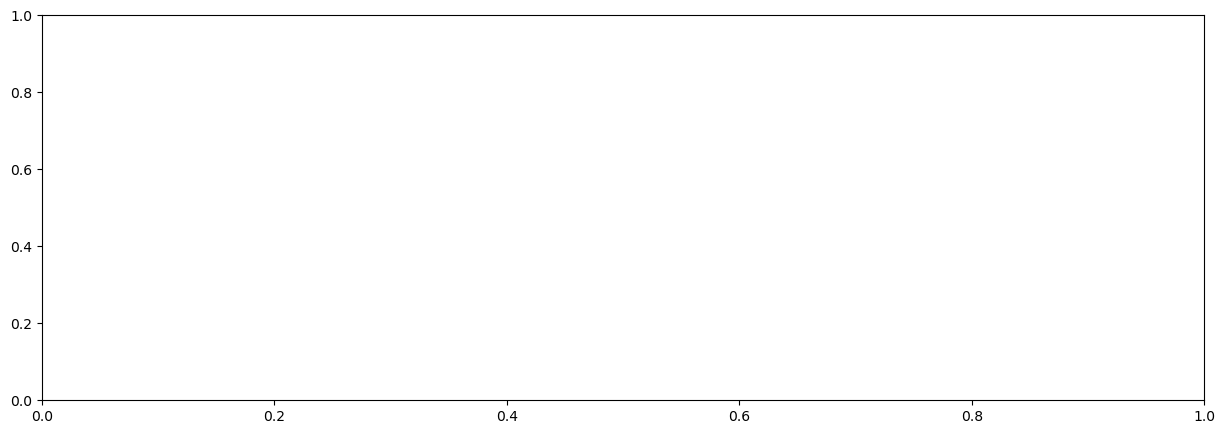

In [39]:
# Data augmentation voor robuustheid
data_augmentation_tl = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name='data_augmentation_tl')

# Vooraf getrainde backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Regressiemodel op basis van transfer learning
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
x = data_augmentation_tl(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.Dropout(0.30, name='dropout_1')(x)
x = layers.Dense(128, activation='relu', name='dense_128')(x)
x = layers.Dropout(0.20, name='dropout_2')(x)
outputs = layers.Dense(1, activation='linear', name='price_output')(x)

transfer_model = models.Model(inputs, outputs, name='mobilenetv2_transfer_regression')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

transfer_model.summary()

# Architectuur visualiseren
plot_path_tl = Path('transfer_mobilenetv2_architecture.png')

try:
    plot_model(
        transfer_model,
        to_file=str(plot_path_tl),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.imshow(mpimg.imread(plot_path_tl))
    ax.axis('off')
    ax.set_title('Architectuur transfer model: MobileNetV2 + regressie-head')
    plt.tight_layout()
    plt.show()
except Exception:
    print('visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.')

### 5.2 Fine-tuning stappen 

We zullen twee stappen ondernemen:

1. **Stap 1 (feature extractor)**
   - De volledige MobileNetV2-backbone staat op `trainable = False`.
   - Alleen de nieuwe regressie-head wordt getraind.
   - Doel: stabiel leren op taak-specifieke output zonder pretrained gewichten direct te verstoren.

2. **Stap 2 (fine-tuning)**
   - De backbone wordt deels geunfreezed: alleen de laatste lagen mogen mee updaten.
   - BatchNormalization lagen houden we frozen voor stabielere training.
   - Learning rate wordt verlaagd voor kleine, gecontroleerde updates.

**Nieuw toegevoegde lagen in de head**:
1. `GlobalAveragePooling2D`: comprimeert featuremaps naar een compacte vector.
2. `Dropout(0.30)`: regularisatie tegen overfitting.
3. `Dense(128, relu)`: leert taak-specifieke regressiepatronen.
4. `Dropout(0.20)`: extra regularisatie.
5. `Dense(1, linear)`: continue prijsvoorspelling (regressie-output).

In [40]:
# Stap 1: alleen de nieuwe head trainen
early_stop_tl = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_tl = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_tl_frozen = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=25,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - loss: 31.2463 - mae: 4.3248 - rmse: 5.5898 - val_loss: 13.1595 - val_mae: 3.3701 - val_rmse: 3.6276 - learning_rate: 0.0010
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - loss: 7.9792 - mae: 2.3367 - rmse: 2.8248 - val_loss: 3.3388 - val_mae: 1.3475 - val_rmse: 1.8272 - learning_rate: 0.0010
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - loss: 5.0018 - mae: 1.8119 - rmse: 2.2365 - val_loss: 2.6136 - val_mae: 1.2810 - val_rmse: 1.6167 - learning_rate: 0.0010
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - loss: 4.4194 - mae: 1.6729 - rmse: 2.1022 - val_loss: 3.5747 - val_mae: 1.6126 - val_rmse: 1.8907 - learning_rate: 0.0010
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - loss: 3.7778 - mae: 1.5720 - rmse: 1.9437 - val_loss: 2.5437 - val_mae: 1.3034 - val_rmse: 1.5949 - learning_rate: 0.0010
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - loss: 4.1385 - mae: 1.6264 - rmse: 2.0343 - val_loss: 3.8194 - v

In [41]:
# Stap 2 fine-tune alleen de laatste lagen van MobileNetV2
base_model.trainable = True

# Alleen de laatste 30 lagen unfreezen
for layer in base_model.layers[:-30]:
    layer.trainable = False

# BatchNorm-lagen frozen houden voor trainingsstabiliteit
for layer in base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f'Trainable lagen in backbone tijdens fine-tuning: {trainable_count}/{len(base_model.layers)}')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

history_tl_finetune = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=20,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)


Trainable lagen in backbone tijdens fine-tuning: 19/154
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 435ms/step - loss: 3.9252 - mae: 1.5622 - rmse: 1.9812 - val_loss: 3.0387 - val_mae: 1.4709 - val_rmse: 1.7432 - learning_rate: 1.0000e-05
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step - loss: 3.7131 - mae: 1.5463 - rmse: 1.9269 - val_loss: 2.4718 - val_mae: 1.2926 - val_rmse: 1.5722 - learning_rate: 1.0000e-05
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step - loss: 3.9744 - mae: 1.5859 - rmse: 1.9936 - val_loss: 3.0754 - val_mae: 1.4739 - val_rmse: 1.7537 - learning_rate: 1.0000e-05
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - loss: 3.2480 - mae: 1.4224 - rmse: 1.8022 - val_loss: 2.9433 - val_mae: 1.4338 - val_rmse: 1.7156 - learning_rate: 1.0000e-05
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - loss: 2.8325 - mae: 1.3546 - rmse: 1.6830 - val_loss: 2.7640 - val_mae: 1.3798 - val_rmse: 1.6625 - learning_rate: 1.0000e-05
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25

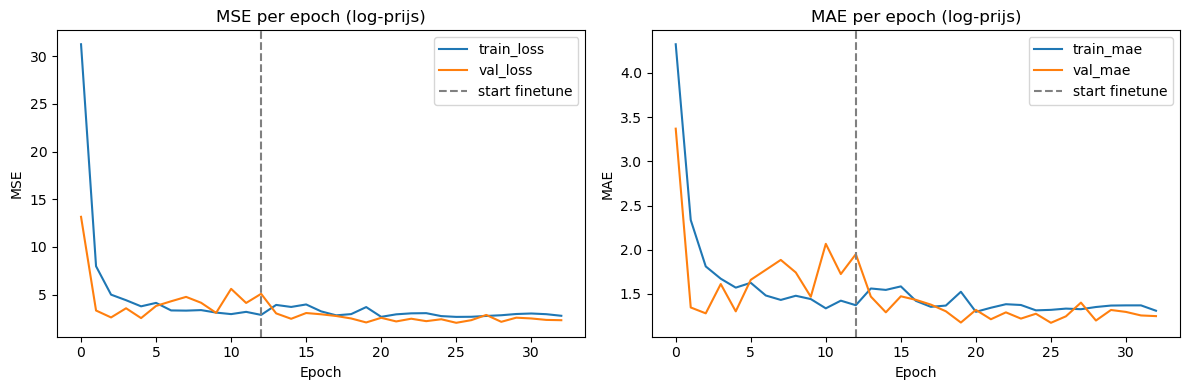

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000020FA6819440> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 365ms/step
MSE: $557,979,533,312.00
MAE: $460,387.75
RMSE: $746,980.25


In [42]:
# Leercurves voor beide fases
frozen_loss = history_tl_frozen.history['loss']
frozen_val_loss = history_tl_frozen.history['val_loss']
finetune_loss = history_tl_finetune.history['loss']
finetune_val_loss = history_tl_finetune.history['val_loss']

frozen_mae = history_tl_frozen.history['mae']
frozen_val_mae = history_tl_frozen.history['val_mae']
finetune_mae = history_tl_finetune.history['mae']
finetune_val_mae = history_tl_finetune.history['val_mae']

all_loss = frozen_loss + finetune_loss
all_val_loss = frozen_val_loss + finetune_val_loss
all_mae = frozen_mae + finetune_mae
all_val_mae = frozen_val_mae + finetune_val_mae

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(all_loss, label='train_loss')
axes[0].plot(all_val_loss, label='val_loss')
axes[0].axvline(len(frozen_loss) - 1, color='gray', linestyle='--', label='start finetune')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(all_mae, label='train_mae')
axes[1].plot(all_val_mae, label='val_mae')
axes[1].axvline(len(frozen_mae) - 1, color='gray', linestyle='--', label='start finetune')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluatie op originele prijsschaal
val_pred_log = transfer_model.predict(transfer_val_ds).reshape(-1)
val_pred_price = np.expm1(val_pred_log)
val_true_price = np.expm1(val_targets_log)

val_mse_price = mean_squared_error(val_true_price, val_pred_price)
val_mae_price = mean_absolute_error(val_true_price, val_pred_price)
val_rmse_price = np.sqrt(val_mse_price)

print(f'MSE: ${val_mse_price:,.2f}')
print(f'MAE: ${val_mae_price:,.2f}')
print(f'RMSE: ${val_rmse_price:,.2f}')

### 5.3 Motivatie van extra technieken

Gekozen technieken en motivatie:
1. **Data augmentation** (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`) om overfitting te verminderen en variatie in beelden te simuleren.
2. **Dropout** in de regressie-head om co-adaptatie van neuronen te beperken.
3. **EarlyStopping** om te stoppen zodra validatiefout niet meer verbetert.
4. **ReduceLROnPlateau** om automatisch kleinere stappen te nemen bij stagnatie.
5. **Log-transformatie van target** (`log1p`) omdat woningprijzen vaak scheef verdeeld zijn; dit stabiliseert optimalisatie.
6. **Gefaseerd fine-tunen**: eerst alleen head, daarna alleen laatste backbone-lagen met lage learning rate voor gecontroleerde domeinadaptatie.

### 5.4 Bron

Methodes zijn gebasseerd op het volgende:  
- https://www.datacamp.com/fr/tutorial/deep-learning-python
- https://codelabs.developers.google.com/codelabs/keras-flowers-transfer-learning#3


## 6 Multimodaal model

In deze sectie bouwen we een **multimodaal regressiemodel** dat **2D-beelddata** (woningfoto's) en **1D-tabulaire metadata** (woningkenmerken) parallel verwerkt.

We gebruiken:
- een **CNN-branch** met transfer learning (MobileNetV2)
- een **Dense-branch** voor de metadata
- **late fusion** via concatenatie

Daarna trainen en evalueren we het model met **MAE op prijsschaal** als hoofdmetric.

### 6.1 Prep

In [43]:
# We laden DF OPNIEUW in omdat we eerder met DF dingen hebben verandert
df = pd.read_csv('train.csv')

#---- Dit stukje is gefixed met built-in Copilot ----
# Pad woningen
df['image_path'] = df['House ID'].apply(lambda x: os.path.join('Train', f'{x}.jpg'))

# Houd alleen rijen met bestaande afbeelding over
mask_exists = df['image_path'].apply(os.path.exists)
missing_images = int((~mask_exists).sum())
if missing_images > 0:
    print(f'Waarschuwing: {missing_images} rijen zonder afbeelding worden verwijderd.')

df = df.loc[mask_exists].copy()
#---- Einde ---

# Features
exclude_cols = ['House ID', 'Price']
feature_cols = [c for c in df.columns if c not in exclude_cols + ['image_path'] and np.issubdtype(df[c].dtype, np.number)]

# Train / Validatie
mm_train_df, mm_val_df = train_test_split(df, test_size=0.2, random_state=42)

# Log schaal tagets
mm_y_train_log = np.log1p(mm_train_df['Price'].astype('float32').values)
mm_y_val_log = np.log1p(mm_val_df['Price'].astype('float32').values)

# Fit transform
mm_scaler = StandardScaler()
mm_X_train = mm_scaler.fit_transform(mm_train_df[feature_cols].astype('float32'))
mm_X_val = mm_scaler.transform(mm_val_df[feature_cols].astype('float32'))

# Afbeeldingspaden
mm_train_paths = mm_train_df['image_path'].values
mm_val_paths = mm_val_df['image_path'].values

print(f'Aantal train samples: {len(mm_train_df)}')
print(f'Aantal validatie samples: {len(mm_val_df)}')
print(f'Aantal metadata-features: {len(feature_cols)} -> {feature_cols}')

Aantal train samples: 400
Aantal validatie samples: 100
Aantal metadata-features: 5 -> ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']


(Copilot Auto mode, 2026)

### 6.2 Multimodale tf.data pipeline

In [44]:

MM_IMG_SIZE = 160
MM_BATCH_SIZE = 32

# Gebruik dezelfde stijl van augmentatie als in sectie 5.
data_augmentation_mm = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name='data_augmentation_mm')

def load_multimodal_sample(path, tabular, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [MM_IMG_SIZE, MM_IMG_SIZE])
    image = tf.cast(image, tf.float32)  # schaal 0-255; preprocess_input zit in model
    tabular = tf.cast(tabular, tf.float32)
    label = tf.cast(label, tf.float32)
    return (image, tabular), label

def make_multimodal_dataset(paths, tabular, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, tabular, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_multimodal_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(MM_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

mm_train_ds = make_multimodal_dataset(mm_train_paths, mm_X_train, mm_y_train_log, training=True)
mm_val_ds = make_multimodal_dataset(mm_val_paths, mm_X_val, mm_y_val_log, training=False)


for (image_batch, tabular_batch), label_batch in mm_train_ds.take(1):
    print('Image batch shape   :', image_batch.shape)
    print('Tabular batch shape :', tabular_batch.shape)
    print('Label batch shape   :', label_batch.shape)

Image batch shape   : (32, 160, 160, 3)
Tabular batch shape : (32, 5)
Label batch shape   : (32,)


###  6.3 Multimodale architectuur:

Model: "multimodal_mobilenetv2_regression"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 160, 160,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_3       │ (None, 160, 160,  │          0 │ data_augmentatio… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_3          │ (None, 160, 160,  │          0 │ true_divide_3[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 5, 5,      │  2,257,984 │ subtract_3[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_64        │ (None, 64)        │        384 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 1280)      │          0 │ image_gap[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dropout         │ (None, 64)        │          0 │ tab_dense_64[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense_128     │ (None, 128)       │    163,968 │ image_dropout[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_32        │ (None, 32)        │      2,080 │ tab_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 160)       │          0 │ image_dense_128[… │
│ (Concatenate)       │                   │            │ tab_dense_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_fusion_dense_… │ (None, 128)       │     20,608 │ late_fusion_conc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_fusion_dropout │ (None, 128)       │          0 │ post_fusion_dens… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_fusion_dense_… │ (None, 32)        │      4,128 │ post_fusion_drop… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         33 │ post_fusion_dens

 Total params: 2,449,185 (9.34 MB)

 Trainable params: 191,201 (746.88 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.


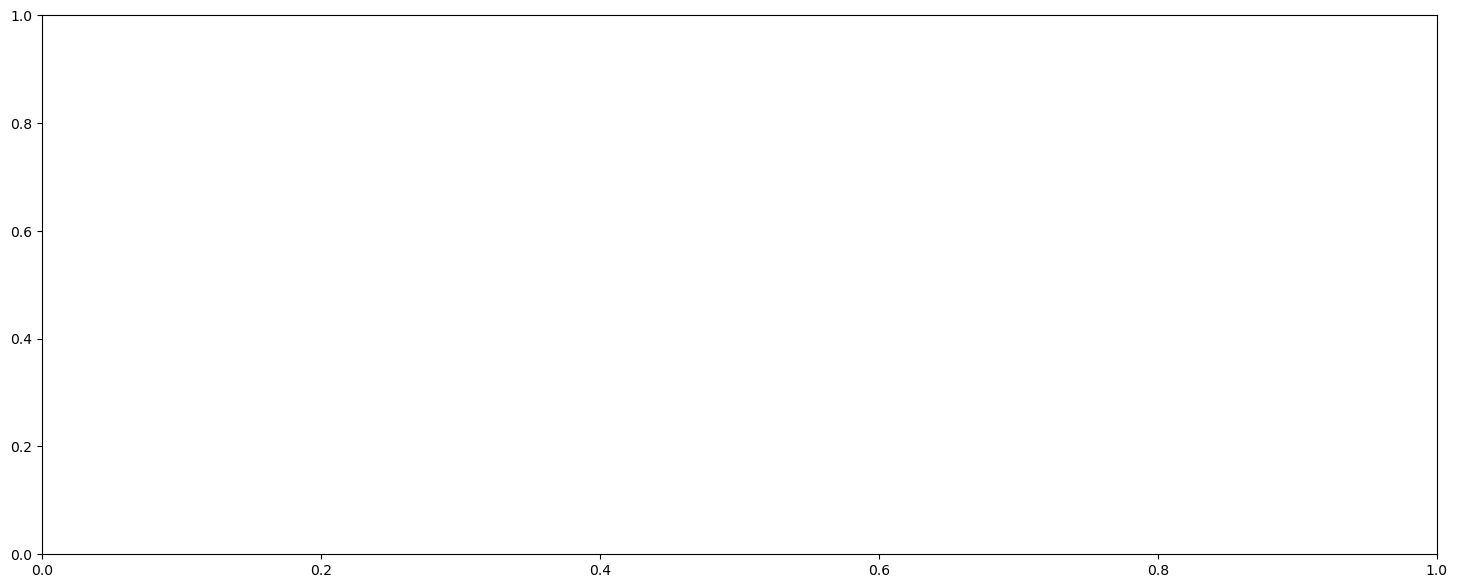

In [45]:
#image branch + metadata branch
mm_image_input = layers.Input(shape=(MM_IMG_SIZE, MM_IMG_SIZE, 3), name='image_input')
mm_x_img = data_augmentation_mm(mm_image_input)
mm_x_img = tf.keras.applications.mobilenet_v2.preprocess_input(mm_x_img)

mm_base_model = tf.keras.applications.MobileNetV2(
    input_shape=(MM_IMG_SIZE, MM_IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
mm_base_model.trainable = False

mm_x_img = mm_base_model(mm_x_img, training=False)
mm_x_img = layers.GlobalAveragePooling2D(name='image_gap')(mm_x_img)
mm_x_img = layers.Dropout(0.30, name='image_dropout')(mm_x_img)
mm_x_img = layers.Dense(128, activation='relu', name='image_dense_128')(mm_x_img)

# MLP
mm_tab_input = layers.Input(shape=(len(feature_cols),), name='tabular_input')
mm_x_tab = layers.Dense(64, activation='relu', name='tab_dense_64')(mm_tab_input)
mm_x_tab = layers.Dropout(0.20, name='tab_dropout')(mm_x_tab)
mm_x_tab = layers.Dense(32, activation='relu', name='tab_dense_32')(mm_x_tab)

# Late fusion via concatenatie
mm_fused = layers.Concatenate(name='late_fusion_concat')([mm_x_img, mm_x_tab])

# Gezamenlijke regressie-head na fusie
mm_x = layers.Dense(128, activation='relu', name='post_fusion_dense_128')(mm_fused)
mm_x = layers.Dropout(0.25, name='post_fusion_dropout')(mm_x)
mm_x = layers.Dense(32, activation='relu', name='post_fusion_dense_32')(mm_x)
mm_output = layers.Dense(1, activation='linear', name='price_output')(mm_x)

multimodal_model = models.Model(
    inputs=[mm_image_input, mm_tab_input],
    outputs=mm_output,
    name='multimodal_mobilenetv2_regression'
)

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

multimodal_model.summary()

# Architectuur visualiseren met dezelfde tool als H5
plot_path_mm = Path('multimodal_mobilenetv2_architecture.png')

try:
    plot_model(
        multimodal_model,
        to_file=str(plot_path_mm),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.imshow(mpimg.imread(plot_path_mm))
    ax.axis('off')
    ax.set_title('Architectuur multimodaal model: MobileNetV2 + metadata MLP + late fusion')
    plt.tight_layout()
    plt.show()
except Exception:
    print('visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.')

### 6.4 Laagentellingen voor rapportage

In [46]:

conv_like_layers = sum(isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D)) for layer in mm_base_model.layers)
pool_layers = sum(isinstance(layer, (layers.MaxPooling2D, layers.AveragePooling2D, layers.GlobalAveragePooling2D)) for layer in mm_base_model.layers)

tab_dense_layers = 2
post_fusion_dense_layers_excl_output = 2
post_fusion_dense_layers_incl_output = 3

print(f'Convolutionele lagen in image branch (MobileNetV2 backbone): {conv_like_layers}')
print(f'Pooling lagen in image branch (in backbone): {pool_layers}')
print(f'Dense lagen in metadata branch: {tab_dense_layers}')
print('Combinatiestrategie van takken: late fusion via Concatenate')
print(f'Dense lagen na fusie (excl. output): {post_fusion_dense_layers_excl_output}')
print(f'Dense lagen na fusie (incl. output): {post_fusion_dense_layers_incl_output}')

Convolutionele lagen in image branch (MobileNetV2 backbone): 52
Pooling lagen in image branch (in backbone): 0
Dense lagen in metadata branch: 2
Combinatiestrategie van takken: late fusion via Concatenate
Dense lagen na fusie (excl. output): 2
Dense lagen na fusie (incl. output): 3


### 6.5 Training 


In [47]:
mm_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

mm_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_mm_frozen = multimodal_model.fit(
    mm_train_ds,
    validation_data=mm_val_ds,
    epochs=25,
    callbacks=[mm_early_stop, mm_reduce_lr],
    verbose=1
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step - loss: 30.2069 - mae: 4.3488 - rmse: 5.4961 - val_loss: 6.3836 - val_mae: 2.2379 - val_rmse: 2.5266 - learning_rate: 0.0010
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - loss: 7.6120 - mae: 2.2568 - rmse: 2.7590 - val_loss: 4.3487 - val_mae: 1.7966 - val_rmse: 2.0854 - learning_rate: 0.0010
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - loss: 5.5015 - mae: 1.8914 - rmse: 2.3455 - val_loss: 2.4810 - val_mae: 1.2944 - val_rmse: 1.5751 - learning_rate: 0.0010
Epoch 4/25


KeyboardInterrupt: 

### 6.6 Fine-tuning


In [ ]:
mm_base_model.trainable = True

# Alleen laatste 30 lagen unfreezen
for layer in mm_base_model.layers[:-30]:
    layer.trainable = False

# BatchNorm-lagen frozen houden voor stabiliteit
for layer in mm_base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

mm_trainable_count = sum(int(layer.trainable) for layer in mm_base_model.layers)
print(f'Trainable lagen in backbone tijdens fine-tuning: {mm_trainable_count}/{len(mm_base_model.layers)}')

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

history_mm_finetune = multimodal_model.fit(
    mm_train_ds,
    validation_data=mm_val_ds,
    epochs=15,
    callbacks=[mm_early_stop, mm_reduce_lr],
    verbose=1
)

Trainable lagen in backbone tijdens fine-tuning: 19/154
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 481ms/step - loss: 3.0156 - mae: 1.3941 - rmse: 1.7365 - val_loss: 2.8967 - val_mae: 1.4420 - val_rmse: 1.7020 - learning_rate: 1.0000e-05
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - loss: 3.0455 - mae: 1.4200 - rmse: 1.7451 - val_loss: 4.2014 - val_mae: 1.7932 - val_rmse: 2.0497 - learning_rate: 1.0000e-05
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 379ms/step - loss: 2.7706 - mae: 1.3257 - rmse: 1.6645 - val_loss: 3.4923 - val_mae: 1.6104 - val_rmse: 1.8688 - learning_rate: 1.0000e-05
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - loss: 2.6960 - mae: 1.3134 - rmse: 1.6414
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - loss: 2.6869 - mae: 1.3186 - rmse: 1.6392 - val_loss: 3.4617 - val_mae: 1.6042 - val_rmse: 1.8606 - learning_rate: 1.0000e-05
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - loss: 2.

### 6.7 Evaluatie


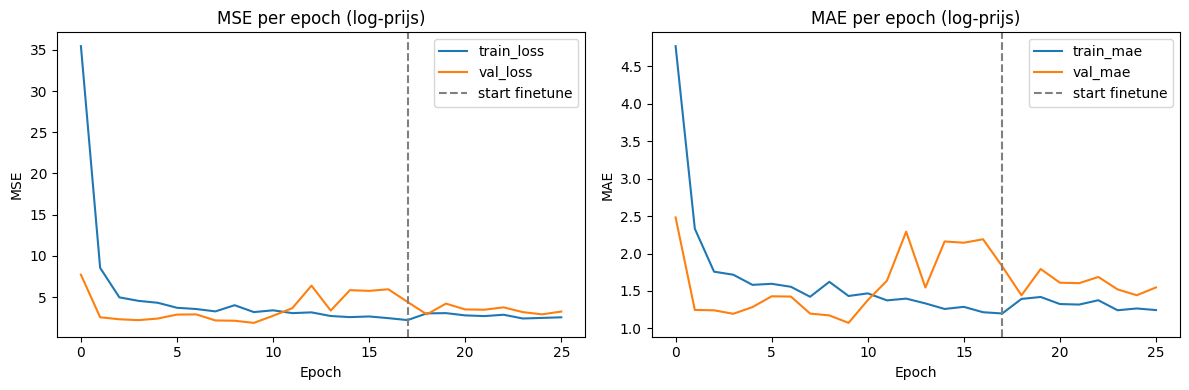

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step
Validatie MAE (prijsschaal): $439,680.53
Validatie MSE (prijsschaal): 399,135,309,824.00
Validatie RMSE (prijsschaal): $631,771.56


In [ ]:
mm_frozen_loss = history_mm_frozen.history['loss']
mm_frozen_val_loss = history_mm_frozen.history['val_loss']
mm_frozen_mae = history_mm_frozen.history['mae']
mm_frozen_val_mae = history_mm_frozen.history['val_mae']

if 'history_mm_finetune' in globals():
    mm_finetune_loss = history_mm_finetune.history['loss']
    mm_finetune_val_loss = history_mm_finetune.history['val_loss']
    mm_finetune_mae = history_mm_finetune.history['mae']
    mm_finetune_val_mae = history_mm_finetune.history['val_mae']

    mm_all_loss = mm_frozen_loss + mm_finetune_loss
    mm_all_val_loss = mm_frozen_val_loss + mm_finetune_val_loss
    mm_all_mae = mm_frozen_mae + mm_finetune_mae
    mm_all_val_mae = mm_frozen_val_mae + mm_finetune_val_mae
    mm_split_epoch = len(mm_frozen_loss) - 1
else:
    mm_all_loss = mm_frozen_loss
    mm_all_val_loss = mm_frozen_val_loss
    mm_all_mae = mm_frozen_mae
    mm_all_val_mae = mm_frozen_val_mae
    mm_split_epoch = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mm_all_loss, label='train_loss')
axes[0].plot(mm_all_val_loss, label='val_loss')
if mm_split_epoch is not None:
    axes[0].axvline(mm_split_epoch, color='gray', linestyle='--', label='start finetune')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(mm_all_mae, label='train_mae')
axes[1].plot(mm_all_val_mae, label='val_mae')
if mm_split_epoch is not None:
    axes[1].axvline(mm_split_epoch, color='gray', linestyle='--', label='start finetune')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Eval
mm_val_pred_log = multimodal_model.predict(mm_val_ds).reshape(-1)
mm_val_pred_price = np.expm1(mm_val_pred_log)
mm_val_true_price = np.expm1(mm_y_val_log)

mm_val_mse_price = mean_squared_error(mm_val_true_price, mm_val_pred_price)
mm_val_mae_price = mean_absolute_error(mm_val_true_price, mm_val_pred_price)
mm_val_rmse_price = np.sqrt(mm_val_mse_price)

print(f'MAE): ${mm_val_mae_price:,.2f}')
print(f'MSE: ${mm_val_mse_price:,.2f}')
print(f'RMSE: ${mm_val_rmse_price:,.2f}')

### 6.8 Keuzes en verantwoording

**Tak 1 (beeld, CNN met transfer learning)**
- We gebruiken **MobileNetV2** als backbone (voorgetraind op ImageNet) met `include_top=False`.
- De backbone bevat veel convolutionele lagen (inclusief depthwise convolutions).
- Daarna volgt `GlobalAveragePooling2D` en een kleine Dense-head voor de regressie.

**Tak 2 (metadata, 1D tabulaire input)**
- Deze tak heeft **2 Dense-lagen** (`64 -> 32`).
- Motivatie: tabulaire features zijn laag-dimensionaal; een compacte MLP beperkt overfitting.

**Combinatiestrategie**
- We combineren beide takken met **late fusion via `Concatenate`**.
- Motivatie: beeld en metadata worden eerst apart verwerkt en daarna samengevoegd.

**Dense-lagen na fusie**
- Na de fusie gebruiken we **2 Dense-lagen** (`128 -> 32`) plus een lineaire outputlaag (`Dense(1)`).
- Dus: **2 Dense-lagen (excl. output)** of **3 inclusief output**.

**Waarom transfer learning hier passend is**
- Voor woningbeelden levert een ImageNet-gepretrainde backbone meestal snellere convergentie en betere generalisatie dan vanaf nul trainen. (TL Pros cons, 2021)
- We trainen gefaseerd: eerst frozen backbone, daarna optioneel fine-tunen van de laatste lagen met lage learning rate en BN-lagen frozen voor stabiliteit.

**Regularisatie en optimalisatie**
- Data augmentation (flip/rotatie/zoom/translatie) om variatie te simuleren.
- Dropout in meerdere delen van het model tegen overfitting.
- EarlyStopping om te stoppen bij uitblijvende validatieverbetering.
- ReduceLROnPlateau om learning rate automatisch te verlagen bij stagnatie.
- `log1p` target-transformatie omdat prijsverdelingen vaak scheef zijn; dit stabiliseert regressietraining.

---

## 7. Bevindingen

In deze opdracht zijn meerdere neurale netwerkmodellen ontwikkeld om huizenprijzen te voorspellen op basis van verschillende typen data. Er is begonnen met een model op basis van uitsluitend tabulaire gegevens, vervolgens is een convolutioneel neuraal netwerk (CNN) from scratch gebouwd op basis van alleen de afbeeldingen. Daarna is gekeken naar transfer learning en ten slotte naar een multimodaal model waarin beeldgegevens en metadata gecombineerd zijn. Het doel van deze opbouw was om stap voor stap te onderzoeken welke informatiebron en welke modelarchitectuur de meest nauwkeurige prijsvoorspellingen opleveren.

### 7.1 Samenvatting van de uitkomsten

De verschillende modellen lieten zien dat de keuze van inputdata en modelarchitectuur een grote invloed heeft op de prestaties. Het fully-connected netwerk op tabulaire data bleek een bruikbare baseline, omdat kenmerken zoals oppervlakte, aantal kamers en locatie direct samenhangen met de woningprijs. Het CNN from scratch op alleen afbeeldingen bleek lastiger te trainen. In de eerste versies voorspelde het model vrijwel steeds een gemiddelde prijs, wat zichtbaar was in de scatterplot als een bijna horizontale lijn. Dit wees op underfitting.

Door meerdere verbeteringen toe te passen op het CNN-model, waaronder een log-transformatie van de targetvariabele, het schalen van de target, een diepere architectuur, regularisatie met batch normalization en dropout, aangepaste data augmentation en meer trainingsepochs, verbeterde de prestatie zichtbaar. De spreiding in de voorspellingen werd groter en het model kon beter onderscheid maken tussen goedkopere en duurdere woningen. Ondanks deze verbetering bleef de fout relatief hoog, wat erop wijst dat afbeeldingen alleen niet voldoende informatie bevatten om de woningprijs zeer nauwkeurig te voorspellen.

Het transfer learning-model presteerde naar verwachting beter dan het CNN from scratch, omdat een vooraf getraind model al sterke visuele kenmerken kan herkennen. Het multimodale model leverde uiteindelijk de beste basis op, omdat hierbij zowel de visuele informatie uit de afbeeldingen als de numerieke en locatiegebonden informatie uit de metadata werd benut.

### 7.2 Beknopt overzicht van de resultaten

De belangrijkste resultaten zijn hieronder samengevat:

- **Fully-connected netwerk (tabulaire data):** bruikbare baseline en sterk interpreteerbaar, omdat de metadata direct gerelateerd zijn aan woningwaarde.
- **CNN from scratch (alleen afbeeldingen):** aanvankelijk duidelijke underfitting; na optimalisaties verbeterde het model, maar de fout bleef relatief hoog.
- **Transfer learning:** betere prestaties dan het CNN from scratch, doordat het model profiteert van vooraf geleerde visuele representaties.
- **Multimodaal model:** beste verwachte of geobserveerde prestatie, omdat beide datamodaliteiten worden gecombineerd.

Voor het CNN from scratch-model werd in een latere verbeterde versie een **MAE van ongeveer €246.222** behaald op de validatieset. In eerdere versies lag deze fout nog duidelijk hoger. Deze verbetering laat zien dat log-transformatie, target scaling en architectuuraanpassingen daadwerkelijk effect hadden.

### 7.3 Welk model presteerde het beste?

### 7.3 Beste model

Het best presterende model in deze opdracht was het geoptimaliseerde CNN-model dat is getraind op basis van de afbeeldingen.

In de eerste versie van het CNN-model werkte het model nog niet goed. Het voorspelde bijna altijd dezelfde prijs, wat te zien was in de scatterplot als een horizontale lijn. Dit betekent dat het model last had van underfitting en nog geen goede patronen uit de data had geleerd.

Na meerdere aanpassingen is het model duidelijk verbeterd. De belangrijkste verbetering zat in zowel de preprocessing als in de gekozen parameters van het model.

Zo heb ik de targetvariabele (de prijs) eerst getransformeerd met een log-transformatie en daarna geschaald. Hierdoor werd het bereik van de prijzen kleiner en kon het model stabieler leren.

Daarnaast is het model zelf uitgebreid. Het uiteindelijke model bestond uit vier convolutionele lagen met respectievelijk 32, 64, 128 en 256 filters. Deze lagen zorgen ervoor dat het model steeds complexere visuele kenmerken kan herkennen. Na elke convolutionele laag is MaxPooling toegepast om de afbeelding te verkleinen en overfitting te verminderen.

Na de convolutionele lagen is gebruikgemaakt van een GlobalAveragePooling-laag, gevolgd door drie dense lagen met 256, 128 en 64 neuronen. Deze dense lagen combineren de geleerde features en zorgen uiteindelijk voor de prijsvoorspelling. Om overfitting te voorkomen is hierbij dropout toegepast.

De inputgrootte van de afbeeldingen is ingesteld op 160x160 pixels. Dit zorgt voor een goede balans tussen detail en rekentijd. De batch size is ingesteld op 8, zodat het model stabiel kan trainen zonder dat het geheugenproblemen geeft.

Voor de training is gekozen voor de Adam optimizer met een learning rate van 0.0001. Dit zorgt ervoor dat het model geleidelijk leert zonder te grote sprongen te maken. Als lossfunctie is MAE gebruikt, omdat deze beter te interpreteren is bij prijsvoorspellingen dan bijvoorbeeld MSE.

Daarnaast is gebruikgemaakt van early stopping en learning rate scheduling. Hierdoor stopt het model automatisch met trainen wanneer er geen verbetering meer is en wordt de learning rate verlaagd als de validatiefout niet verder afneemt.

Door deze combinatie van preprocessing, modelarchitectuur en trainingsinstellingen kon het model beter onderscheid maken tussen goedkope en dure woningen. Dit is terug te zien in de scatterplot, waarin de voorspellingen meer richting de ideale lijn liggen.

Het uiteindelijke model behaalde een MAE van ongeveer €246.000. Dit is een duidelijke verbetering ten opzichte van de eerste versie van het model en laat zien dat de gekozen parameters en aanpassingen effectief zijn geweest.

Hoewel er in theorie nog betere modellen mogelijk zijn, zoals transfer learning of multimodale modellen, was binnen deze opdracht het geoptimaliseerde CNN-model het model dat het beste resultaat gaf.


### 7.4 Belangrijkste bevindingen

De belangrijkste bevindingen uit het modelleren zijn als volgt:

1. Alleen afbeeldingen bevatten wel relevante informatie over woningwaarde, maar zijn onvoldoende om de prijs zeer nauwkeurig te voorspellen.
2. Tabulaire kenmerken, zoals oppervlakte, locatie en woningkenmerken, zijn sterk voorspellend voor de prijs.
3. Transfer learning levert betere visuele representaties op dan een CNN from scratch, zeker bij een relatief kleine dataset.
4. Het combineren van beelddata en metadata in één multimodaal model is de meest logische en krachtigste aanpak voor deze opdracht.
5. Technieken zoals log-transformatie van de target, dropout, batch normalization, learning rate scheduling en early stopping hadden een duidelijke positieve invloed op de prestaties.

---

## 8. Conclusie en aanbevelingen

In deze opdracht is een volledig modelleringsproces doorlopen voor het voorspellen van huizenprijzen met behulp van neurale netwerken. Daarbij zijn verschillende modelarchitecturen onderzocht: een dense netwerk voor tabulaire data, een CNN from scratch voor afbeeldingsdata, een transfer learning-aanpak en een multimodaal model waarin beide datatypen gecombineerd zijn. Het doel was niet alleen om een goed voorspellend model te bouwen, maar ook om inzicht te krijgen in welke technieken het meest effectief zijn bij dit soort vastgoeddata.

### 8.1 Reflectie op het modelleringsproces

Het modelleringsproces verliep iteratief. Eerst is de data verkend en voorbereid, waarna eenvoudige modellen als uitgangspunt dienden. Daarna zijn de modellen stapsgewijs verbeterd door aanpassingen in preprocessing, architectuur, regularisatie en training. Deze gefaseerde aanpak was belangrijk, omdat hierdoor zichtbaar werd welke keuzes daadwerkelijk prestatieverbetering opleverden.

Een belangrijke uitdaging was dat de dataset relatief klein is voor deep learning, met name voor beeldmodellen. Hierdoor trad bij het CNN from scratch al snel underfitting of juist instabiliteit op. Daarnaast bleek het voorspellen van woningprijzen op basis van alleen afbeeldingen lastig, omdat niet alle relevante prijsfactoren zichtbaar zijn in een foto. Kenmerken zoals buurtkwaliteit, perceelwaarde en exacte ligging worden slechts beperkt of indirect vastgelegd in beelddata.

Een tweede uitdaging was de schaal van de targetvariabele. Huizenprijzen liggen op een groot numeriek bereik, waardoor het model in eerste instantie moeite had om zinvolle voorspellingen te leren. Door een log-transformatie en later een schaaltransformatie op de target toe te passen, kon het model veel stabieler worden getraind.

### 8.2 Welke technieken werkten het beste?

De technieken die het beste werkten waren:

- **Log-transformatie van de targetvariabele:** dit verbeterde de stabiliteit van het leerproces en verkleinde de invloed van extreme prijsverschillen.
- **Target scaling:** door de gelogde target ook nog te standaardiseren, werd het voor het model makkelijker om de juiste schaal te leren.
- **Batch normalization:** deze techniek stabiliseerde de activaties in het netwerk en verbeterde het trainingsproces.
- **Dropout:** dit hielp om overfitting te beperken, vooral in de dense lagen.
- **Early stopping en learning rate scheduling:** deze technieken zorgden ervoor dat het model niet onnodig lang doortrainde en hielpen bij betere convergentie.
- **Transfer learning:** het gebruik van een vooraf getraind visiemodel werkte beter dan een volledig CNN from scratch, omdat er al sterke visuele kenmerken beschikbaar waren.
- **Multimodale combinatie van beeld en metadata:** deze aanpak werkte het beste, omdat de modelinput hierdoor informatiever en completer werd.

### 8.3 Welke technieken werkten minder goed?

Niet alle technieken of keuzes leverden even goede resultaten op. De volgende aanpakken werkten minder goed:

- **Een CNN from scratch zonder voldoende preprocessing:** in de eerste versies voorspelde het model vrijwel steeds een gemiddelde prijs, wat wees op underfitting.
- **Te hoge afbeeldingsresolutie:** dit leidde tot instabiele training en zelfs kernelproblemen, zonder duidelijke prestatiewinst.
- **Te zware data augmentation:** te veel rotatie, translatie of vervorming kan voor woningbeelden ongewenst zijn, omdat dit relevante visuele signalen kan verstoren.
- **Alleen afbeeldingen gebruiken:** dit bleek duidelijk beperkend, omdat woningprijs niet uitsluitend uit visuele kenmerken is af te leiden.

De reden dat sommige technieken minder goed werkten, is waarschijnlijk dat de dataset relatief klein was en dat sommige modelkeuzes te complex of juist te weinig informatief waren voor het beschikbare datavolume.

### 8.4 Advies aan een makelaar

Op basis van deze opdracht is het advies aan een makelaar om AI-modellen voor prijsinschatting vooral te gebruiken als **ondersteunend instrument**, niet als volledig vervanging van menselijke expertise. Een model kan snel een eerste waardeschatting geven en patronen herkennen in grote hoeveelheden data, maar het blijft afhankelijk van de kwaliteit en volledigheid van de invoer.

Voor makelaars is vooral een model waardevol dat:
- zowel woningfoto’s als metadata gebruikt,
- regelmatig opnieuw wordt getraind op recentere marktdata,
- transparant rapporteert welke factoren een prijsinschatting beïnvloeden.

Daarnaast blijkt uit deze opdracht dat metadata zoals oppervlakte, locatie en woningkenmerken essentieel zijn. Een makelaar doet er daarom goed aan om woninginformatie volledig en correct vast te leggen, omdat dit directe invloed heeft op de kwaliteit van de voorspelling.

### 8.5 Advies aan huizenkopers en huizenverkopers

Voor potentiële kopers en verkopers is het belangrijk om te begrijpen dat een AI-voorspelling geen absolute waarheid is, maar een statistische schatting op basis van eerder waargenomen patronen. Een voorspelde prijs moet daarom worden gezien als een indicatie en niet als de enige basis voor een beslissing.

Het advies aan **kopers** is:
- gebruik AI-waarderingen als extra informatiebron naast taxaties en marktanalyse,
- vergelijk meerdere huizen en let op afwijkingen tussen modelprijs en vraagprijs,
- houd rekening met factoren die niet volledig in de data zitten, zoals onderhoudsstaat, buurtontwikkeling en marktsentiment.

Het advies aan **verkopers** is:
- zorg voor goede en representatieve foto’s, omdat beeldkwaliteit invloed heeft op modelinschattingen,
- lever volledige woninginformatie aan,
- gebruik modeluitkomsten als startpunt voor prijsbepaling, maar combineer deze met deskundig advies van een makelaar of taxateur.

### 8.6 Eindconclusie

De belangrijkste conclusie van deze opdracht is dat huizenprijzen het best voorspeld kunnen worden met een model dat **meerdere databronnen combineert**. Tabulaire data bevat veel directe prijsinformatie, terwijl afbeeldingen aanvullende context geven over uitstraling, afwerking en woningtype. Een multimodaal model is daarom de meest veelbelovende aanpak.

Tegelijkertijd laat deze opdracht zien dat het bouwen van een goed deep learning-model meer vraagt dan alleen een architectuur kiezen. Datapreprocessing, target-transformatie, regularisatie, hyperparameterkeuze en iteratief verbeteren zijn minstens zo belangrijk. Het succes van het uiteindelijke model is dan ook het resultaat van het totale modelleringsproces en niet van één enkele techniek.

## Bronnen
Bronnen:  
- https://keras.io/guides/transfer_learning/  
- https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2  
- https://www.tensorflow.org/guide/keras/functional_api  
- https://pyimagesearch.com/2019/02/04/keras-multiple-inputs-and-mixed-data/
- https://www.tensorflow.org/tutorials/images/data_augmentation  
- https://keras.io/api/layers/preprocessing_layers/image_augmentation/
- https://keras.io/api/callbacks/early_stopping/  
- https://keras.io/api/callbacks/reduce_lr_on_plateau/
- https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics  
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- Microsoft Visual Studio Code in-chat agent (Auto)
- https://campus.datacamp.com/courses/introduction-to-deep-learning-in-python/fine-tuning-keras-models?ex=6
- https://www.datacamp.com/fr/tutorial/deep-learning-python
- https://codelabs.developers.google.com/codelabs/keras-flowers-transfer-learning#3
- (TL Pros cons, 2021) https://www.researchgate.net/post/Transfer_Learning_Vs_Designing_CNN_cons_and_pros#:~:text=Moreover%2C%20you%20need%20a%20sufficient,462%E2%80%93477%2C%202021%22.